In [1]:
import os

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
from config import ROOT, MIN_FREQ

from src.data.STL_dataset import SLTDataset
from src.models.SLT_model import SLTModel
from src.utils.vocabulary import Vocabulary
import torch
from torch.nn.utils.rnn import pad_sequence
import pandas as pd
from tqdm import tqdm

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DATA_PATH = rf"{ROOT}\datasets\processed\i3d_features"
CSV_PATH = rf"{ROOT}\datasets\annotations\how2sign_train.csv"
SAVE_DIR = rf"{ROOT}\models"
BATCH_SIZE = 2
EPOCHS = 10
LR = 1e-4

PAD_IDX = 0
SOS_IDX = 1
EOS_IDX = 2

In [2]:
def align(left, right):
    T = min(left.shape[0], right.shape[0])

    left = left[:, :T]
    right = right[:, :T]

    return left, right


def collate_fn(batch):

    lefts = [x[0] for x in batch]
    rights = [x[1] for x in batch]
    texts = [x[2] for x in batch]

    lefts = pad_sequence(
        lefts,
        batch_first=True
    )

    rights = pad_sequence(
        rights,
        batch_first=True
    )

    texts = pad_sequence(
        texts,
        batch_first=True,
        padding_value=PAD_IDX
    )

    return lefts, rights, texts

df = pd.read_csv(CSV_PATH, sep="\t")

vocab = Vocabulary(MIN_FREQ)

for s in tqdm(df["SENTENCE"].tolist()):

    vocab.build_vocab(
        s.lower().split()
    )
dataset = SLTDataset(DATA_PATH, vocab)


100%|██████████| 31165/31165 [00:41<00:00, 747.92it/s] 


In [3]:
# Sample
left, right, gt_text = dataset[0]
print(left.shape, right.shape)
print(f"Text: { gt_text}")
T = min(left.shape[0], right.shape[0])

left = left[:T, :]
right = right[:T, :]

left = left.unsqueeze(0).to(DEVICE)
right = right.unsqueeze(0).to(DEVICE)

torch.Size([88, 512]) torch.Size([88, 512])
Text: tensor([   1,    5,   23,  558,   46, 1856, 2046,  110,  581,   62,  166, 4132,
          12,   22,    4,   12,    3,    5,  287,    8, 3568,    2])


C:\Users\2507\AppData\Local\Temp\ipykernel_19512\1767371388.py:10: UserWarning: expandable_segments not supported on this platform (Triggered internally at C:\cb\pytorch_1000000000000\work\c10/cuda/CUDAAllocatorConfig.h:28.)
  left = left.unsqueeze(0).to(DEVICE)


In [4]:
MODEL_PATH = rf"{ROOT}\models\26.05.27.best_model.pt"
model = SLTModel(
    vocab_size=len(vocab.word2idx)
).to(DEVICE)

checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

C:\Users\2507\.conda\envs\pytorch\lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
C:\Users\2507\AppData\Local\Temp\ipykernel_19512\404156364.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_onl

SLTModel(
  (fusion): Linear(in_features=1024, out_features=512, bias=True)
  (encoder): TemporalEncoder(
    (position): PositionalEncoding()
    (encoder): TransformerEncoder(
      (layers): ModuleList(
        (0-3): 4 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=512, out_features=512, bias=True)
          )
          (linear1): Linear(in_features=512, out_features=2048, bias=True)
          (dropout): Dropout(p=0.3, inplace=False)
          (linear2): Linear(in_features=2048, out_features=512, bias=True)
          (norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.3, inplace=False)
          (dropout2): Dropout(p=0.3, inplace=False)
        )
      )
    )
    (norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  )
  (decoder): TextDecoder(
    (embedding): Embed

In [6]:
tokens = [SOS_IDX]

for _ in range(20):

    inp = torch.tensor(tokens).unsqueeze(0).to(DEVICE)

    out = model(left, right, inp)

    next_token = out[:, -1].argmax(-1).item()

    tokens.append(next_token)

    if next_token == EOS_IDX:
        break

pred_sentence = vocab.decode(tokens)
gt_sentence = vocab.decode(gt_text.tolist())
print(len(str.split(pred_sentence, sep=" ")))
print("PRED:", pred_sentence)
print("GT  :", gt_sentence)

20
PRED: so if you have a <UNK> you can do it on your <UNK> you can actually do a little bit
GT  : and i call them decorative elements because basically all they're meant to do is to <UNK> and color the page.


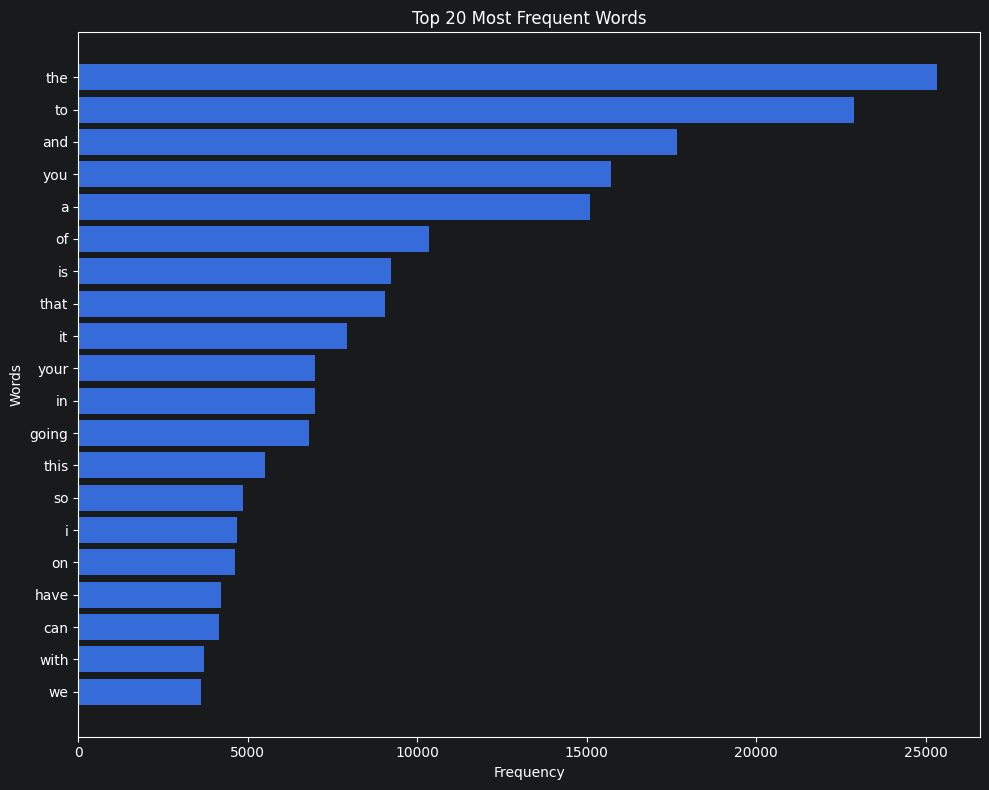

In [4]:
from collections import Counter
import matplotlib.pyplot as plt

counter = vocab.counter

top_words = counter.most_common(20)

words = [x[0] for x in top_words]
counts = [x[1] for x in top_words]

plt.figure(figsize=(10, 8))

plt.barh(words, counts)

plt.xlabel("Frequency")
plt.ylabel("Words")
plt.title("Top 20 Most Frequent Words")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()